In [22]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Project paths
CLEAN_PATH = Path(r"C:\Data Science\DS Projects\Internet Traffic\Datasets\ITU\Clean")
CHARTS_PATH = Path(r"C:\Data Science\DS Projects\Internet Traffic\Charts")

# Load clean data
df = pd.read_csv(CLEAN_PATH / "itu_internet_users_2005_2023_clean.csv")

print(f"Rows: {len(df)}")
df

Rows: 19


,year,internet_pct,population,internet_users_millions
0,2005,15.6,6575841506,1025.8
1,2006,17.2,6659977025,1145.5
2,2007,20.2,6744489399,1362.4
3,2008,22.8,6830513541,1557.4
4,2009,25.3,6916589116,1749.9
5,2010,28.4,7001266876,1988.4
6,2011,30.9,7087120034,2189.9
7,2012,33.3,7176929184,2389.9
8,2013,35.3,7265892332,2564.9
9,2014,37.4,7354068030,2750.4


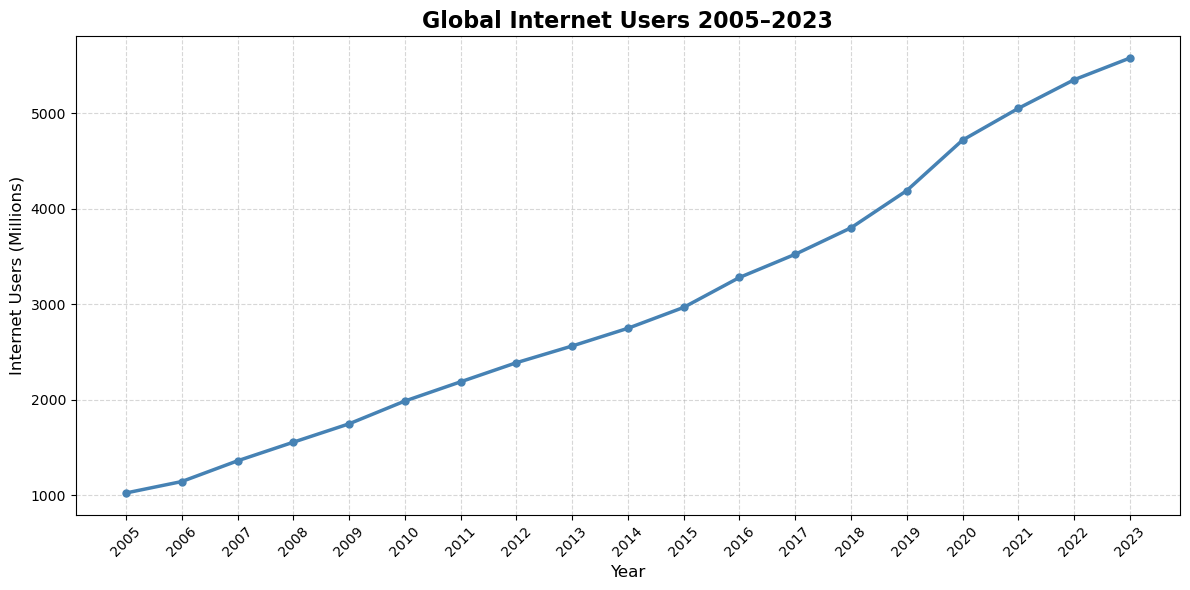

In [23]:
# Baseline plot — global internet users 2005–2023

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df["year"], df["internet_users_millions"], color="steelblue", linewidth=2.5, marker="o", markersize=5)

ax.set_title("Global Internet Users 2005–2023", fontsize=16, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Internet Users (Millions)", fontsize=12)
ax.set_xticks(df["year"])
ax.tick_params(axis="x", rotation=45)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(CHARTS_PATH / "01_baseline_internet_users.png", dpi=150, bbox_inches="tight")
plt.show()

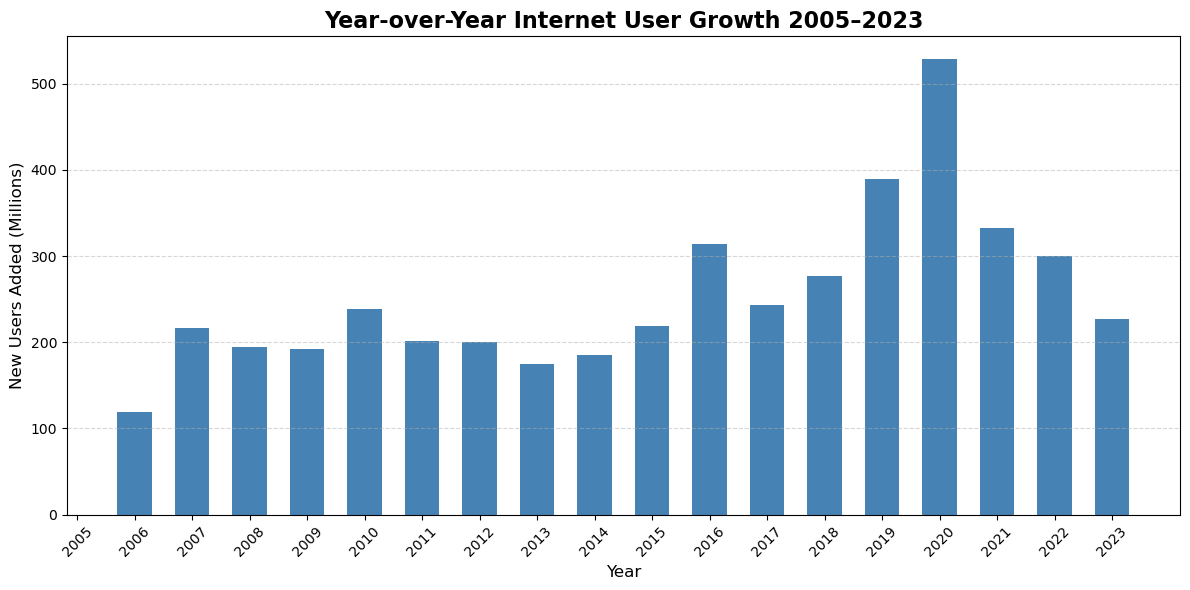

In [24]:
# Year-over-year change in internet users (millions added per year)

df["yoy_change"] = df["internet_users_millions"].diff()

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(df["year"], df["yoy_change"], color="steelblue", width=0.6)

ax.set_title("Year-over-Year Internet User Growth 2005–2023", fontsize=16, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("New Users Added (Millions)", fontsize=12)
ax.set_xticks(df["year"])
ax.tick_params(axis="x", rotation=45)
ax.grid(True, linestyle="--", alpha=0.5, axis="y")

plt.tight_layout()
plt.savefig(CHARTS_PATH / "02_yoy_internet_growth.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# Identify peaks and troughs in YoY growth

from scipy.signal import argrelextrema
import numpy as np

# Find local maxima and minima
df_yoy = df.dropna(subset=["yoy_change"]).reset_index(drop=True)

peak_idx   = argrelextrema(df_yoy["yoy_change"].values, np.greater, order=1)[0]
trough_idx = argrelextrema(df_yoy["yoy_change"].values, np.less, order=1)[0]

peaks   = df_yoy.loc[peak_idx, ["year", "yoy_change"]]
troughs = df_yoy.loc[trough_idx, ["year", "yoy_change"]]

print("Peaks:")
print(peaks.to_string(index=False))
print("\nTroughs:")
print(troughs.to_string(index=False))

Peaks:
 year  yoy_change
 2007       216.9
 2010       238.5
 2016       313.4
 2020       528.4

Troughs:
 year  yoy_change
 2009       192.5
 2013       175.0
 2017       242.9


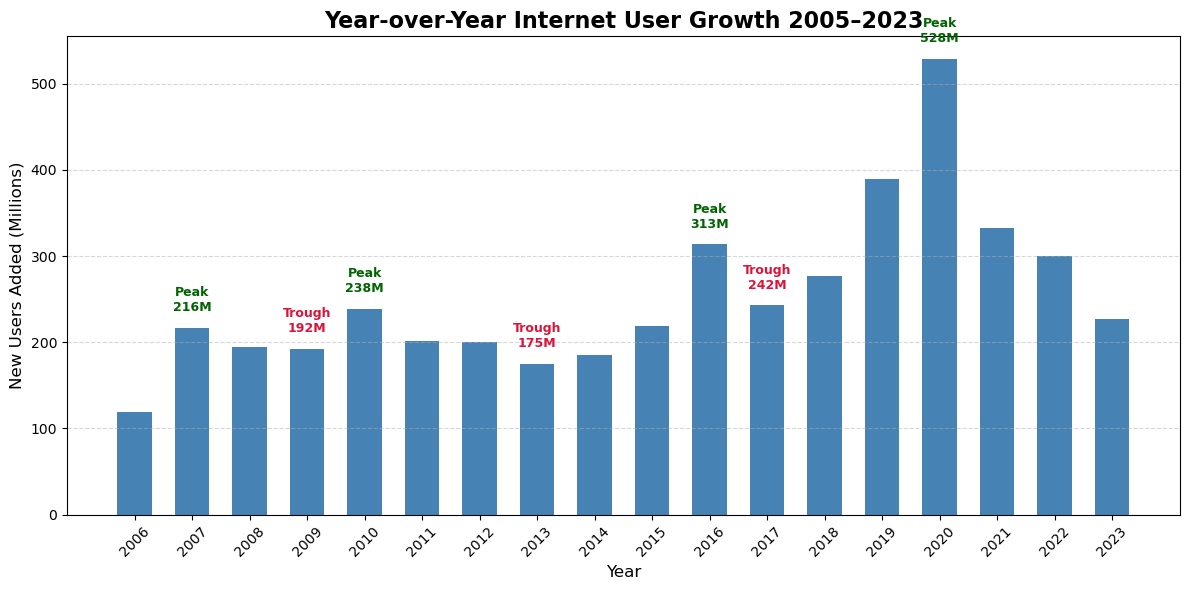

In [26]:
# Annotate bar chart with peaks and troughs

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(df_yoy["year"], df_yoy["yoy_change"], color="steelblue", width=0.6)

# Annotate peaks
for _, row in peaks.iterrows():
    ax.annotate(f"Peak\n{int(row['yoy_change'])}M",
                xy=(row["year"], row["yoy_change"]),
                xytext=(0, 12), textcoords="offset points",
                ha="center", fontsize=9, color="darkgreen", fontweight="bold")

# Annotate troughs
for _, row in troughs.iterrows():
    ax.annotate(f"Trough\n{int(row['yoy_change'])}M",
                xy=(row["year"], row["yoy_change"]),
                xytext=(0, 12), textcoords="offset points",
                ha="center", fontsize=9, color="crimson", fontweight="bold")

ax.set_title("Year-over-Year Internet User Growth 2005–2023", fontsize=16, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("New Users Added (Millions)", fontsize=12)
ax.set_xticks(df_yoy["year"])
ax.tick_params(axis="x", rotation=45)
ax.grid(True, linestyle="--", alpha=0.5, axis="y")

plt.tight_layout()
plt.savefig(CHARTS_PATH / "03_yoy_annotated.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
# Fetch global GDP growth rate from World Bank API
# Indicator NY.GDP.MKTP.KD.ZG = GDP growth rate (annual %)
# WLD = global aggregate, 2005-2023

WB_GDP_URL = (
    "https://api.worldbank.org/v2/country/WLD/indicator/NY.GDP.MKTP.KD.ZG"
    "?format=json&per_page=100&date=2005:2023"
)

r_gdp = requests.get(WB_GDP_URL, timeout=10)

print("Status code:", r_gdp.status_code)
print("Preview:", r_gdp.text[:500])

Status code: 200
Preview: [{"page":1,"pages":1,"per_page":100,"total":19,"sourceid":"2","lastupdated":"2026-04-08"},[{"indicator":{"id":"NY.GDP.MKTP.KD.ZG","value":"GDP growth (annual %)"},"country":{"id":"1W","value":"World"},"countryiso3code":"WLD","date":"2023","value":2.94859475004874,"unit":"","obs_status":"","decimal":1},{"indicator":{"id":"NY.GDP.MKTP.KD.ZG","value":"GDP growth (annual %)"},"country":{"id":"1W","value":"World"},"countryiso3code":"WLD","date":"2022","value":3.40305483746891,"unit":"","obs_status":"


In [29]:
# Save raw GDP JSON to Raw folder

raw_gdp_path = Path(r"C:\Data Science\DS Projects\Internet Traffic\Datasets\ITU\Raw") / "wb_gdp_growth_raw.json"

with open(raw_gdp_path, "w") as f:
    json.dump(r_gdp.json(), f, indent=2)

print("Saved:", raw_gdp_path)

Saved: C:\Data Science\DS Projects\Internet Traffic\Datasets\ITU\Raw\wb_gdp_growth_raw.json


In [30]:
# Save raw GDP JSON to World Bank Raw folder

raw_gdp_path = Path(r"C:\Data Science\DS Projects\Internet Traffic\Datasets\World Bank\Raw") / "wb_gdp_growth_raw.json"

with open(raw_gdp_path, "w") as f:
    json.dump(r_gdp.json(), f, indent=2)

print("Saved:", raw_gdp_path)

Saved: C:\Data Science\DS Projects\Internet Traffic\Datasets\World Bank\Raw\wb_gdp_growth_raw.json


In [31]:
# Parse GDP growth data into a DataFrame

gdp_data = r_gdp.json()[1]

df_gdp = pd.DataFrame([
    {"year": int(rec["date"]), "gdp_growth": round(rec["value"], 2)}
    for rec in gdp_data
    if rec["value"] is not None
]).sort_values("year").reset_index(drop=True)

# Merge with existing dataframe
df = pd.merge(df, df_gdp, on="year")

print(f"Rows: {len(df)}")
df

Rows: 19


,year,internet_pct,population,internet_users_millions,yoy_change,gdp_growth
0,2005,15.6,6575841506,1025.8,NaN,4.05
1,2006,17.2,6659977025,1145.5,119.7,4.48
2,2007,20.2,6744489399,1362.4,216.9,4.41
3,2008,22.8,6830513541,1557.4,195.0,2.09
4,2009,25.3,6916589116,1749.9,192.5,-1.32
5,2010,28.4,7001266876,1988.4,238.5,4.52
6,2011,30.9,7087120034,2189.9,201.5,3.34
7,2012,33.3,7176929184,2389.9,200.0,2.73
8,2013,35.3,7265892332,2564.9,175.0,2.89
9,2014,37.4,7354068030,2750.4,185.5,3.13


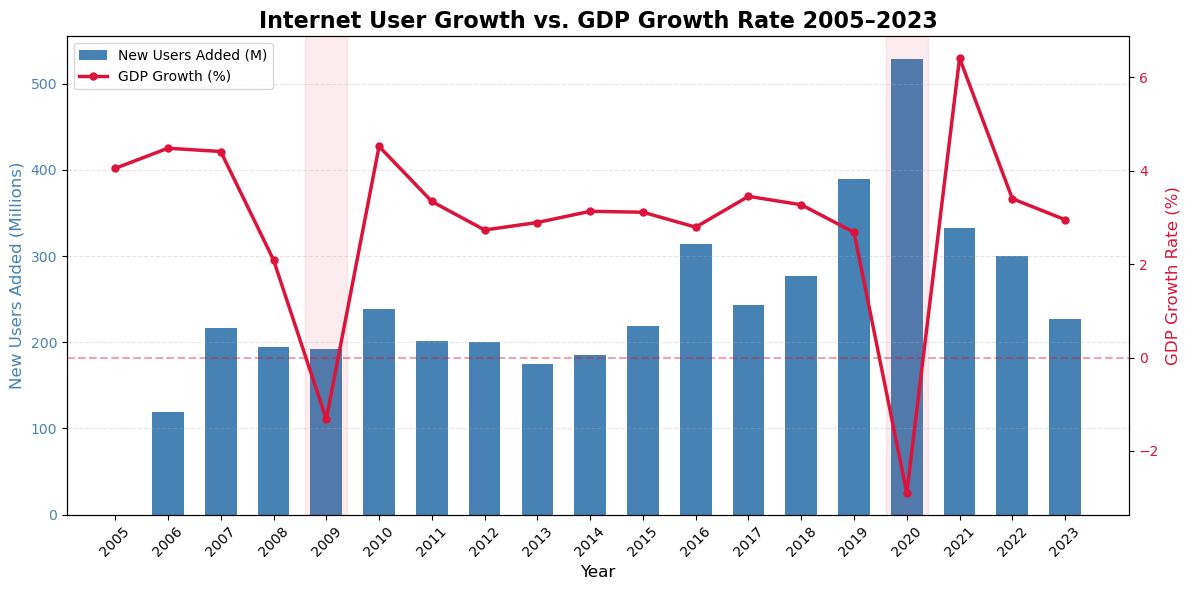

In [32]:
# Dual axis chart — internet user growth vs GDP growth rate

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis — YoY internet user growth (bars)
ax1.bar(df["year"], df["yoy_change"], color="steelblue", width=0.6, label="New Users Added (M)")
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("New Users Added (Millions)", fontsize=12, color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(df["year"])
ax1.tick_params(axis="x", rotation=45)

# Right axis — GDP growth rate (line)
ax2 = ax1.twinx()
ax2.plot(df["year"], df["gdp_growth"], color="crimson", linewidth=2.5, marker="o", markersize=5, label="GDP Growth (%)")
ax2.set_ylabel("GDP Growth Rate (%)", fontsize=12, color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.axhline(y=0, color="crimson", linestyle="--", alpha=0.4)

# Annotate recession years
for year, gdp in zip(df["year"], df["gdp_growth"]):
    if gdp < 0:
        ax1.axvspan(year - 0.4, year + 0.4, color="crimson", alpha=0.08)

ax1.set_title("Internet User Growth vs. GDP Growth Rate 2005–2023", fontsize=16, fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.3, axis="y")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig(CHARTS_PATH / "04_users_vs_gdp.png", dpi=150, bbox_inches="tight")
plt.show()

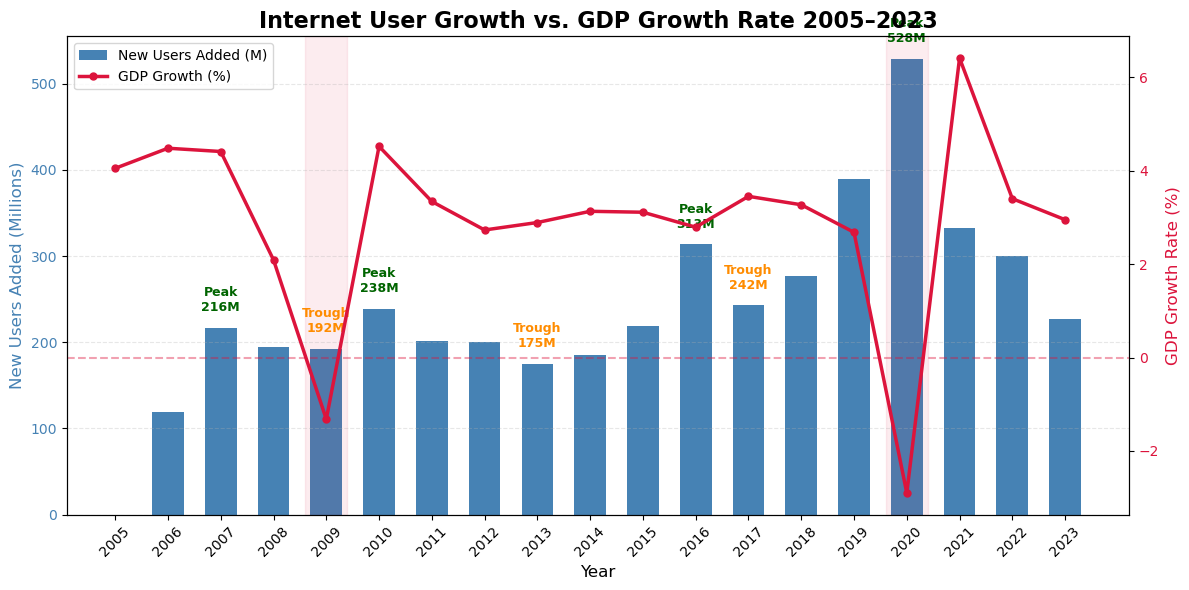

In [33]:
# Dual axis chart with peak and trough annotations

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis — YoY internet user growth (bars)
ax1.bar(df["year"], df["yoy_change"], color="steelblue", width=0.6, label="New Users Added (M)")
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("New Users Added (Millions)", fontsize=12, color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(df["year"])
ax1.tick_params(axis="x", rotation=45)

# Right axis — GDP growth rate (line)
ax2 = ax1.twinx()
ax2.plot(df["year"], df["gdp_growth"], color="crimson", linewidth=2.5, marker="o", markersize=5, label="GDP Growth (%)")
ax2.set_ylabel("GDP Growth Rate (%)", fontsize=12, color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.axhline(y=0, color="crimson", linestyle="--", alpha=0.4)

# Shade recession years
for year, gdp in zip(df["year"], df["gdp_growth"]):
    if gdp < 0:
        ax1.axvspan(year - 0.4, year + 0.4, color="crimson", alpha=0.08)

# Annotate peaks
for _, row in peaks.iterrows():
    ax1.annotate(f"Peak\n{int(row['yoy_change'])}M",
                xy=(row["year"], row["yoy_change"]),
                xytext=(0, 12), textcoords="offset points",
                ha="center", fontsize=9, color="darkgreen", fontweight="bold")

# Annotate troughs
for _, row in troughs.iterrows():
    ax1.annotate(f"Trough\n{int(row['yoy_change'])}M",
                xy=(row["year"], row["yoy_change"]),
                xytext=(0, 12), textcoords="offset points",
                ha="center", fontsize=9, color="darkorange", fontweight="bold")

ax1.set_title("Internet User Growth vs. GDP Growth Rate 2005–2023", fontsize=16, fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.3, axis="y")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig(CHARTS_PATH / "05_users_vs_gdp_annotated.png", dpi=150, bbox_inches="tight")
plt.show()